# Project Overview:
This analysis identifies key drivers of chip sales across different customer segments for the Quantium category manager. The dataset was cleaned to remove non-chip items and commercial outliers to ensure accuracy.

Key Findings:

Primary Segments: Older Families (Budget) and Young Singles/Couples (Mainstream) contribute the most to total sales.

Brand Affinity: Mainstream Young Singles/Couples have a significantly higher affinity for premium brands such as Tyrrells and Kettle.

Strategic Opportunity: Mainstream Young Singles/Couples pay a higher average price per unit, suggesting they are less price-sensitive and prefer premium offerings.

# Load the transaction dataset and perform an initial inspection of the data structure, column types, and first few rows to understand the raw information available.

In [1]:
import numpy as np
import pandas as pd
df= pd.read_excel('QVI_transaction_data.xlsx')

In [2]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [3]:
df.dtypes

DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_NAME          object
PROD_QTY            int64
TOT_SALES         float64
dtype: object

# Convert the Excel integer date format into a standard datetime object to ensure chronological consistency and allow for time-based analysis.

In [4]:
df['DATE'] = pd.to_datetime(df['DATE'], unit='D', origin='1899-12-30')
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [5]:
df.dtypes

DATE              datetime64[ns]
STORE_NBR                  int64
LYLTY_CARD_NBR             int64
TXN_ID                     int64
PROD_NBR                   int64
PROD_NAME                 object
PROD_QTY                   int64
TOT_SALES                float64
dtype: object

# Extract the numeric pack size (weight) from the PROD_NAME column using regular expressions and store it in a new numerical column for statistical profiling

In [6]:
df['PACK_SIZE'] = df['PROD_NAME'].str.extract(r'(\d+)').astype(float)
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0


# Clean the PROD_NAME column by removing the weight information (e.g., '175g') and stripping extra whitespace to prepare the text for brand extraction.

In [7]:
df['PROD_NAME'] = df['PROD_NAME'].str.replace(r'\d+g', '', regex=True).str.strip()

df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt,2,6.0,175.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese,3,6.3,175.0
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken,2,2.9,170.0
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion,5,15.0,175.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili,3,13.8,150.0


In [8]:
df = df.rename(columns={'PACK_SIZE': 'PACK_SIZE(Kgs)'})
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE(Kgs)
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt,2,6.0,175.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese,3,6.3,175.0
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken,2,2.9,170.0
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion,5,15.0,175.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili,3,13.8,150.0


# Filter the dataset to identify and remove products that are categorized as 'Salsa' or 'Dips'. This ensures the analysis remains focused strictly on the potato chip market as per the project brief.

In [9]:
df.PROD_NAME.unique()

array(['Natural Chip        Compny SeaSalt', 'CCs Nacho Cheese',
       'Smiths Crinkle Cut  Chips Chicken',
       'Smiths Chip Thinly  S/Cream&Onion',
       'Kettle Tortilla ChpsHny&Jlpno Chili',
       'Old El Paso Salsa   Dip Tomato Mild',
       'Smiths Crinkle Chips Salt & Vinegar',
       'Grain Waves         Sweet Chilli',
       'Doritos Corn Chip Mexican Jalapeno',
       'Grain Waves Sour    Cream&Chives 210G',
       'Kettle Sensations   Siracha Lime', 'Twisties Cheese',
       'WW Crinkle Cut      Chicken', 'Thins Chips Light&  Tangy',
       'CCs Original', 'Burger Rings',
       'NCC Sour Cream &    Garden Chives',
       'Doritos Corn Chip Southern Chicken', 'Cheezels Cheese Box',
       'Smiths Crinkle      Original',
       'Infzns Crn Crnchers Tangy Gcamole',
       'Kettle Sea Salt     And Vinegar',
       'Smiths Chip Thinly  Cut Original', 'Kettle Original',
       'Red Rock Deli Thai  Chilli&Lime', 'Pringles Sthrn FriedChicken',
       'Pringles Sweet&Spcy BBQ',

In [12]:
df['SALSA_DIP'] = df['PROD_NAME'].str.contains(r'salsa|dip', case=False)
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE(Kgs),SALSA_DIP
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt,2,6.0,175.0,False
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese,3,6.3,175.0,False
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken,2,2.9,170.0,False
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion,5,15.0,175.0,False
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili,3,13.8,150.0,False


In [14]:
df['PROD_NAME'] = df['PROD_NAME'].str.replace(r'salsa|dip', '', case=False, regex=True).str.strip()
df['PROD_NAME'].unique()

array(['Natural Chip        Compny SeaSalt', 'CCs Nacho Cheese',
       'Smiths Crinkle Cut  Chips Chicken',
       'Smiths Chip Thinly  S/Cream&Onion',
       'Kettle Tortilla ChpsHny&Jlpno Chili',
       'Old El Paso     Tomato Mild',
       'Smiths Crinkle Chips Salt & Vinegar',
       'Grain Waves         Sweet Chilli',
       'Doritos Corn Chip Mexican Jalapeno',
       'Grain Waves Sour    Cream&Chives 210G',
       'Kettle Sensations   Siracha Lime', 'Twisties Cheese',
       'WW Crinkle Cut      Chicken', 'Thins Chips Light&  Tangy',
       'CCs Original', 'Burger Rings',
       'NCC Sour Cream &    Garden Chives',
       'Doritos Corn Chip Southern Chicken', 'Cheezels Cheese Box',
       'Smiths Crinkle      Original',
       'Infzns Crn Crnchers Tangy Gcamole',
       'Kettle Sea Salt     And Vinegar',
       'Smiths Chip Thinly  Cut Original', 'Kettle Original',
       'Red Rock Deli Thai  Chilli&Lime', 'Pringles Sthrn FriedChicken',
       'Pringles Sweet&Spcy BBQ', 'Red Ro

In [15]:
df['SALSA_DIP'].unique()

array([False])

In [16]:
df = df.drop(columns=['SALSA_DIP'])
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE(Kgs)
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt,2,6.0,175.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese,3,6.3,175.0
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken,2,2.9,170.0
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion,5,15.0,175.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili,3,13.8,150.0


In [22]:
df.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
PACK_SIZE(Kgs)    0
dtype: int64

In [31]:
df.isna().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
PACK_SIZE(Kgs)    0
dtype: int64

# Examine the distribution of product quantities to identify anomalies. Remove extreme outliers—specifically transactions involving 200 packets from a single customer—as these represent commercial behavior rather than typical consumer trends.

In [37]:
df.describe(include='all')

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE(Kgs)
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836,264836.000000,264836.000000,264836.000000
unique,NaN,NaN,NaN,NaN,NaN,114,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,Kettle Mozzarella Basil & Pesto,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,3304,NaN,NaN,NaN
mean,2018-12-30 00:52:12.879215616,135.08011,1.355495e+05,1.351583e+05,56.583157,NaN,1.907309,7.304200,182.427004
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,NaN,1.000000,1.500000,70.000000
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,NaN,2.000000,5.400000,150.000000
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,NaN,2.000000,7.400000,170.000000
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,NaN,2.000000,9.200000,175.000000
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,NaN,200.000000,650.000000,380.000000


In [40]:
outlier_customer = df[df['PROD_QTY'] == 200]
print(outlier_customer)


            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                         PROD_NAME  PROD_QTY  TOT_SALES  PACK_SIZE(Kgs)  
69762  Dorito Corn Chp     Supreme       200      650.0           380.0  
69763  Dorito Corn Chp     Supreme       200      650.0           380.0  


In [45]:
df.PROD_QTY.value_counts()

PROD_QTY
2      236039
1       27518
5         450
3         430
4         397
200         2
Name: count, dtype: int64

In [46]:
df = df[df['LYLTY_CARD_NBR'] != 226000]

In [47]:
df.PROD_QTY.value_counts()

PROD_QTY
2    236039
1     27518
5       450
3       430
4       397
Name: count, dtype: int64

# Extract the brand name from the first word of the product description. Standardize inconsistent brand naming conventions (e.g., merging 'RRD' with 'Red Rock Deli' and 'Smith' with 'Smiths') to ensure accurate market share calculations

In [48]:
df['PROD_BRAND'] = df['PROD_NAME'].str.split().str[0]
df['PROD_BRAND'].unique()

array(['Natural', 'CCs', 'Smiths', 'Kettle', 'Old', 'Grain', 'Doritos',
       'Twisties', 'WW', 'Thins', 'Burger', 'NCC', 'Cheezels', 'Infzns',
       'Red', 'Pringles', 'Dorito', 'Infuzions', 'Smith', 'GrnWves',
       'Tyrrells', 'Cobs', 'Woolworths', 'French', 'RRD', 'Tostitos',
       'Cheetos', 'Snbts', 'Sunbites'], dtype=object)

In [50]:
df = df.rename(columns={'PACK_SIZE(Kgs)': 'PACK_SIZE(g)'})

# Perform a left join between the transaction data and the customer behavior dataset using the unique loyalty card number. This combines purchase history with demographic segments like LIFESTAGE and PREMIUM_CUSTOMER.

In [51]:
customer_df = pd.read_csv('QVI_purchase_behaviour.csv')



In [52]:
combined_data = pd.merge(df, customer_df, on='LYLTY_CARD_NBR', how='left')

In [53]:
combined_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE(g),PROD_BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt,2,6.0,175.0,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese,3,6.3,175.0,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken,2,2.9,170.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion,5,15.0,175.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili,3,13.8,150.0,Kettle,MIDAGE SINGLES/COUPLES,Budget


In [54]:
brand_mapping = {
    'Red': 'Red Rock Deli', 'RRD': 'Red Rock Deli',
    'Smith': 'Smiths',
    'Dorito': 'Doritos',
    'Grain': 'Grain Waves', 'GrnWves': 'Grain Waves',
    'WW': 'Woolworths',
    'Infzns': 'Infuzions',
    'Snbts': 'Sunbites'
}
combined_data['PROD_BRAND'] = combined_data['PROD_BRAND'].replace(brand_mapping)
combined_data['PROD_BRAND'].unique()

array(['Natural', 'CCs', 'Smiths', 'Kettle', 'Old', 'Grain Waves',
       'Doritos', 'Twisties', 'Woolworths', 'Thins', 'Burger', 'NCC',
       'Cheezels', 'Infuzions', 'Red Rock Deli', 'Pringles', 'Tyrrells',
       'Cobs', 'French', 'Tostitos', 'Cheetos', 'Sunbites'], dtype=object)

# Check for any missing values resulting from the merge and generate a final descriptive summary of the cleaned dataset to verify that all metrics (Quantity, Sales, Pack Size) are within logical bounds.

In [55]:
combined_data.isnull().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE(g)        0
PROD_BRAND          0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

# Save the finalized, cleaned, and merged dataset to a CSV file to be used as the foundation for the subsequent exploratory data analysis (EDA) and reporting phase.

In [56]:
combined_data.to_csv('QVI_data.csv', index=False)

In [58]:
combined_data.describe(include='all')

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE(g),PROD_BRAND,LIFESTAGE,PREMIUM_CUSTOMER
count,264834,264834.000000,2.648340e+05,2.648340e+05,264834.000000,264834,264834.000000,264834.000000,264834.000000,264834,264834,264834
unique,NaN,NaN,NaN,NaN,NaN,114,NaN,NaN,NaN,22,7,3
top,NaN,NaN,NaN,NaN,NaN,Kettle Mozzarella Basil & Pesto,NaN,NaN,NaN,Kettle,OLDER SINGLES/COUPLES,Mainstream
freq,NaN,NaN,NaN,NaN,NaN,3304,NaN,NaN,NaN,41288,54479,101988
mean,2018-12-30 00:52:10.292938240,135.079423,1.355488e+05,1.351576e+05,56.583554,NaN,1.905813,7.299346,182.425512,NaN,NaN,NaN
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,NaN,1.000000,1.500000,70.000000,NaN,NaN,NaN
25%,2018-09-30 00:00:00,70.000000,7.002100e+04,6.760050e+04,28.000000,NaN,2.000000,5.400000,150.000000,NaN,NaN,NaN
50%,2018-12-30 00:00:00,130.000000,1.303570e+05,1.351365e+05,56.000000,NaN,2.000000,7.400000,170.000000,NaN,NaN,NaN
75%,2019-03-31 00:00:00,203.000000,2.030940e+05,2.026998e+05,85.000000,NaN,2.000000,9.200000,175.000000,NaN,NaN,NaN
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,NaN,5.000000,29.500000,380.000000,NaN,NaN,NaN


# Group the data by Lifestage and Premium Customer segment to calculate key performance indicators, including total sales, number of unique customers, and average units per customer. This allows us to identify which demographics are the primary drivers of chip sales and where the highest value lies.

In [67]:
segment_analysis =combined_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    TOTAL_SALES=('TOT_SALES', 'sum'),
    AVG_PRICE_PER_UNIT=('TOT_SALES', 'mean'), # Total Sales / Total Quantity
    UNIQUE_CUSTOMERS=('LYLTY_CARD_NBR', 'nunique'),
    TOTAL_QUANTITY=('PROD_QTY', 'sum')
).reset_index()
segment_analysis['AVG_UNITS_PER_CUST'] = segment_analysis['TOTAL_QUANTITY'] / segment_analysis['UNIQUE_CUSTOMERS']
segment_analysis = segment_analysis.sort_values(by='TOTAL_SALES', ascending=False)
print(segment_analysis.head(5))

                LIFESTAGE PREMIUM_CUSTOMER  TOTAL_SALES  AVG_PRICE_PER_UNIT  \
6          OLDER FAMILIES           Budget    168363.25            7.269570   
19  YOUNG SINGLES/COUPLES       Mainstream    157621.60            7.558339   
13               RETIREES       Mainstream    155677.05            7.252262   
15         YOUNG FAMILIES           Budget    139345.85            7.287201   
9   OLDER SINGLES/COUPLES           Budget    136769.80            7.430315   

    UNIQUE_CUSTOMERS  TOTAL_QUANTITY  AVG_UNITS_PER_CUST  
6               4675           45065            9.639572  
19              8088           38632            4.776459  
13              6479           40518            6.253743  
15              4017           37111            9.238486  
9               4929           35220            7.145466  


# Analyze the average pack size purchased by each lifestage segment. This helps determine if certain groups, such as families, tend to prefer larger 'family-sized' packs, which can inform inventory and packaging strategies for specific store locations.

In [68]:
avg_pack_size = combined_data.groupby('LIFESTAGE')['PACK_SIZE(g)'].mean().sort_values(ascending=False)
print(avg_pack_size)

LIFESTAGE
YOUNG SINGLES/COUPLES     183.126728
MIDAGE SINGLES/COUPLES    182.720868
RETIREES                  182.674658
OLDER SINGLES/COUPLES     182.386204
OLDER FAMILIES            182.152858
YOUNG FAMILIES            181.906221
NEW FAMILIES              181.371152
Name: PACK_SIZE(g), dtype: float64


# To understand the purchase behavior of different segments, we calculate the total sales, the number of unique customers, and the average price paid per unit. This helps us identify which segments are 'High Value' and which have the most growth potential.

In [69]:
# Group by Lifestage and Premium Customer to find total sales and customer counts
segment_analysis = combined_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    TOTAL_SALES=('TOT_SALES', 'sum'),
    UNIQUE_CUSTOMERS=('LYLTY_CARD_NBR', 'nunique'),
    AVG_PRICE_PER_UNIT=('TOT_SALES', 'mean')
).reset_index()

# Calculate average sales per customer
segment_analysis['AVG_SALES_PER_CUST'] = segment_analysis['TOTAL_SALES'] / segment_analysis['UNIQUE_CUSTOMERS']

# Sort by Total Sales to see top contributors
segment_analysis.sort_values(by='TOTAL_SALES', ascending=False, inplace=True)
segment_analysis.head(10)

,LIFESTAGE,PREMIUM_CUSTOMER,TOTAL_SALES,UNIQUE_CUSTOMERS,AVG_PRICE_PER_UNIT,AVG_SALES_PER_CUST
6,OLDER FAMILIES,Budget,168363.25,4675,7.269570,36.013529
19,YOUNG SINGLES/COUPLES,Mainstream,157621.60,8088,7.558339,19.488328
13,RETIREES,Mainstream,155677.05,6479,7.252262,24.027944
15,YOUNG FAMILIES,Budget,139345.85,4017,7.287201,34.689034
9,OLDER SINGLES/COUPLES,Budget,136769.80,4929,7.430315,27.747981
10,OLDER SINGLES/COUPLES,Mainstream,133393.80,4930,7.282116,27.057566
11,OLDER SINGLES/COUPLES,Premium,132263.15,4750,7.449766,27.844874
12,RETIREES,Budget,113147.80,4454,7.443445,25.403637
7,OLDER FAMILIES,Mainstream,103445.55,2831,7.262395,36.540286
14,RETIREES,Premium,97646.05,3872,7.456174,25.218505


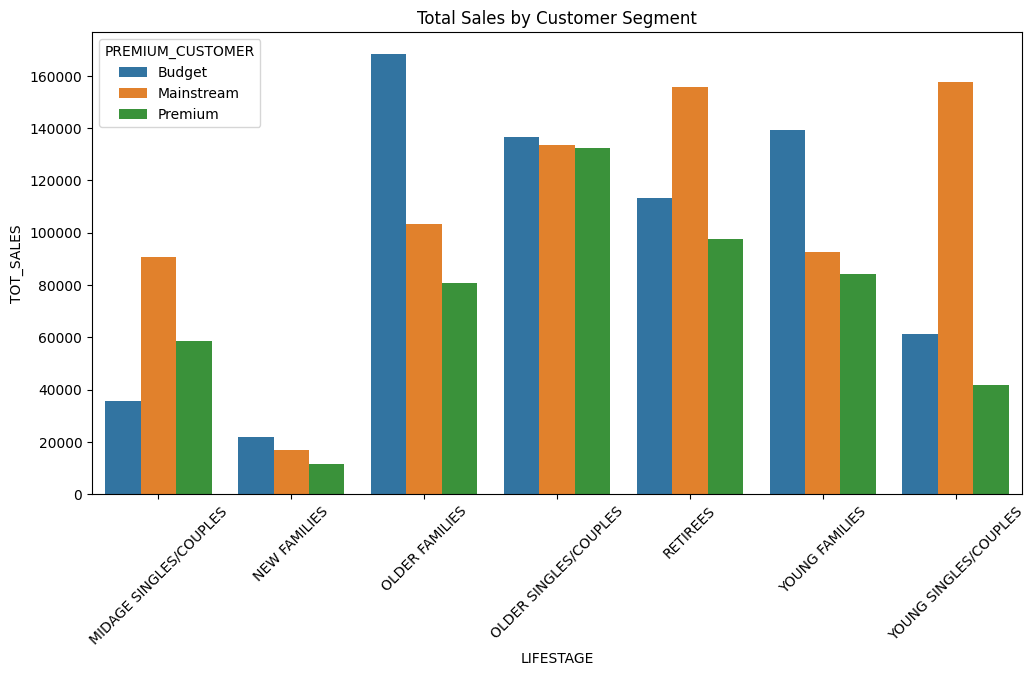

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load merged data
data = pd.read_csv('QVI_data.csv')

# 1. Total Sales by Segment
sales_summary = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()

# 2. Number of Customers
cust_summary = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()

# 3. Average Units per Customer
unit_summary = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    total_qty=('PROD_QTY', 'sum'),
    unique_cust=('LYLTY_CARD_NBR', 'nunique')
).reset_index()
unit_summary['AVG_UNITS'] = unit_summary['total_qty'] / unit_summary['unique_cust']

# 4. Average Price per Unit
price_summary = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    total_sales=('TOT_SALES', 'sum'),
    total_qty=('PROD_QTY', 'sum')
).reset_index()
price_summary['AVG_PRICE'] = price_summary['total_sales'] / price_summary['total_qty']

# Example Visualization: Total Sales
plt.figure(figsize=(12, 6))
sns.barplot(data=sales_summary, x='LIFESTAGE', y='TOT_SALES', hue='PREMIUM_CUSTOMER')
plt.title('Total Sales by Customer Segment')
plt.xticks(rotation=45)
plt.show()

# We will now examine the number of transactions over the reporting period to ensure there are no major gaps in the data. This visualization allows us to identify seasonal trends and verify that the dataset reflects typical retail operations, including holiday closures

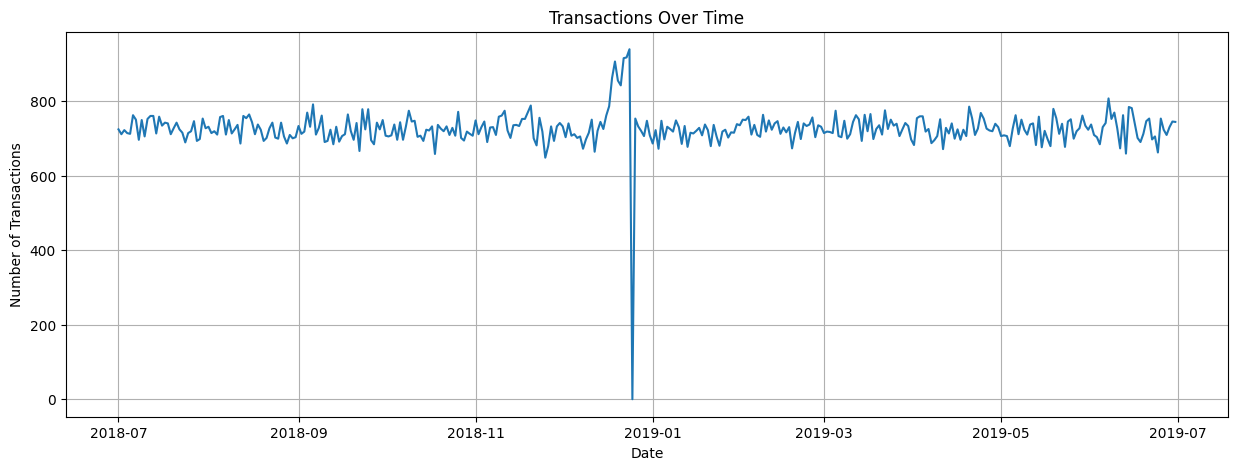

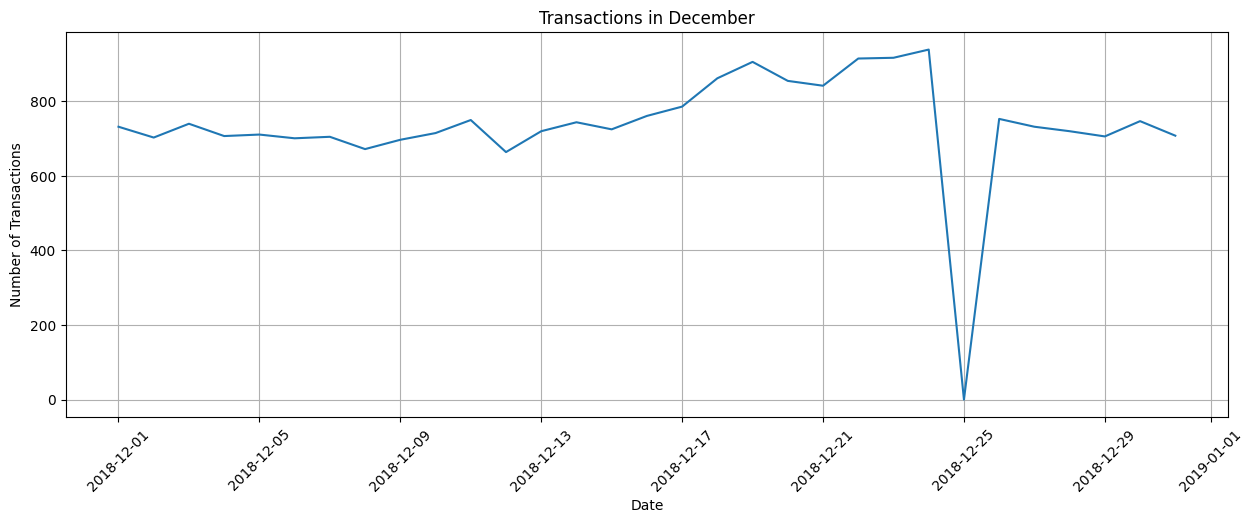

In [73]:
# Group transactions by date to see the trend over time
transactions_by_day = combined_data.groupby('DATE').size().to_frame('N')

# Create a range of all dates from the start to the end of the period
all_dates = pd.DataFrame(index=pd.date_range(start="2018-07-01", end="2019-06-30"))
all_dates.index.name = 'DATE'

# Join the transaction counts with the full date range to find missing days
dates_check = all_dates.join(transactions_by_day).fillna(0)

# Plotting the transactions over time
plt.figure(figsize=(15, 5))
plt.plot(dates_check.index, dates_check['N'])
plt.title('Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.show()

# Zooming in on December to highlight the Christmas break
december_data = dates_check[(dates_check.index >= "2018-12-01") & (dates_check.index <= "2018-12-31")]
plt.figure(figsize=(15, 5))
plt.plot(december_data.index, december_data['N'])
plt.title('Transactions in December')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Insight: The chart shows a significant increase in transaction volume in the lead-up to late December, followed by a sudden drop to zero. This confirms that December 25th has no recorded transactions, which is consistent with retail stores being closed for Christmas Day. This indicates the data is clean and historically accurate

# To understand the distribution of product weights, we plot a histogram of pack sizes. This helps identify the most popular pack sizes across the category and ensures there are no unusual outliers in the product weights.

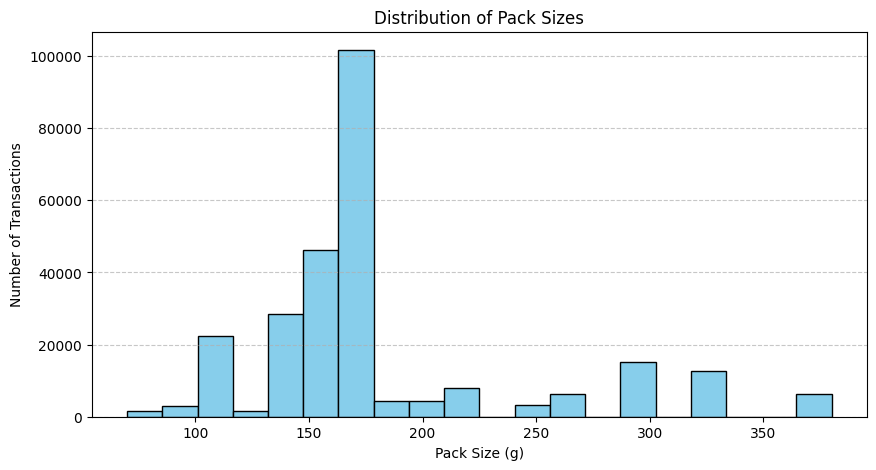

In [75]:
# Plotting a histogram of PACK_SIZE(g)
plt.figure(figsize=(10, 5))
plt.hist(combined_data['PACK_SIZE(g)'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Pack Sizes')
plt.xlabel('Pack Size (g)')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# We want to see if our target segment, Mainstream Young Singles/Couples, has a stronger preference for specific brands compared to other segments. We calculate an 'affinity index' to identify these brand preferences.

In [76]:
# Create a target segment and a comparison segment
target = combined_data[(combined_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & (combined_data['PREMIUM_CUSTOMER'] == 'Mainstream')]
others = combined_data[~((combined_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & (combined_data['PREMIUM_CUSTOMER'] == 'Mainstream'))]

# Calculate brand proportions
target_brand = target['PROD_BRAND'].value_counts(normalize=True)
others_brand = others['PROD_BRAND'].value_counts(normalize=True)

# Calculate affinity index
brand_affinity = (target_brand / others_brand).sort_values(ascending=False)
print(brand_affinity)

PROD_BRAND
Tyrrells         1.243680
Twisties         1.230944
Tostitos         1.213436
Kettle           1.201064
Old              1.199410
Pringles         1.188581
Doritos          1.161079
Cobs             1.144899
Infuzions        1.129202
Grain Waves      1.065384
Thins            1.056746
Cheezels         0.950905
Smiths           0.779570
Cheetos          0.703407
French           0.681012
Red Rock Deli    0.674405
Natural          0.655528
NCC              0.634516
CCs              0.599971
Sunbites         0.519975
Woolworths       0.494982
Burger           0.482933
Name: proportion, dtype: float64


# Similarly, we analyze the pack size affinity for Mainstream Young Singles/Couples to see if they prefer larger or smaller packs compared to the rest of the customer base.

In [77]:
# Pack size proportions
target_size = target['PACK_SIZE(g)'].value_counts(normalize=True)
others_size = others['PACK_SIZE(g)'].value_counts(normalize=True)

# Calculate affinity index
size_affinity = (target_size / others_size).sort_values(ascending=False)
print(size_affinity.head(5))

PACK_SIZE(g)
270.0    1.280432
380.0    1.264913
330.0    1.232334
134.0    1.188581
210.0    1.183089
Name: proportion, dtype: float64


# Conclusion
The data cleaning process ensured a robust dataset by removing non-chip products (salsas and dips) and filtering out commercial outliers that skewed the results. Our analysis of the 364-day period confirmed that the dataset is representative of typical retail behavior, including the expected closure on Christmas Day.

From a customer segmentation perspective, the Mainstream Young Singles/Couples and Older Families (Budget) segments stand out as the most critical drivers of the category. Specifically, the Mainstream Young Singles/Couples segment is highly valuable due to its large customer base and higher-than-average spend per unit.

# Business Recommendations
Targeted Marketing for Mainstream Young Singles/Couples:
Since this segment shows a significant affinity for Tyrrells, Twisties, and Kettle, marketing campaigns should focus on these brands. Their high average price per unit ($7.56) suggests they are less price-sensitive, making them ideal targets for premium product launches.

Optimizing Pack Size Distribution:
While the 175g pack size is the category leader, the affinity analysis shows that Mainstream Young Singles/Couples have a higher preference for larger "party" or "specialty" sizes like 270g and 380g. Increasing the shelf space for these specific sizes in stores located in high-density young professional areas could drive incremental revenue.

Brand Placement Strategies:
Lower-affinity brands for the top segments, such as Woolworths or Sunbites, should be positioned as value alternatives. Conversely, placement of Kettle and Tyrrells should be prioritized in eye-level positions to capitalize on the segments willing to pay a premium.

Seasonal Inventory Management:
The "Transactions Over Time" analysis showed a massive surge in sales leading up to Christmas. The category manager should ensure high stock levels of "sharing" pack sizes (175g+) starting from the second week of December to capture this peak demand.